# Fit.ly Tech Subscriber Churn Analysis

## 1. Project Overview

Fit.ly Tech is a subscription-based fitness platform with a strong national footprint, serving customers across all 50 U.S. states. Over the past two quarters, leadership has observed a notable increase in subscriber churn and is seeking to understand the underlying drivers as well as identify actionable retention strategies.

Customer retention has become increasingly critical for the business. Acquisition costs continue to rise, and each lost subscriber places additional pressure on both Marketing and Product teams. Leadership has asked for a clear, data driven assessment of what is contributing to churn and a set of practical, high impact recommendations to implement in the upcoming quarter.

## 2. Data Overview

The analysis integrated three datasets: account_info, customer_support, and user_activity.

### 2.1 Dataset: account_info

- `customer_id:` Unique identifier for the customer.
- `email:` Customer's email address, used for identification.
- `state:` Geographic location (State) where the customer is located.
- `plan:` The subscription tier chosen by the user (Free, Basic, Pro, or Enterprise).
- `plan_list_price:` The list price of the subscription plan in USD.
- `churn_status:` Target variable indicating if the customer has left the service.

### 2.2 Dataset: customer_support

- `ticket_time:` Timestamp when the support ticket was created by the customer.
- `user_id:` Unique identifier for the customer.
- `channel:` Communication method used for support (e.g., Email, Chat, Phone).
- `topic:` The primary subject or category of the customer support ticket.
- `resolution_time_hours:` Total time taken to resolve a support ticket, measured in hours.
- `state:` Customer support ticket status
- `comments:` GDPR requests to erase or remove data from Fit.ly company records

### 2.3 Dataset: user_activity

- `event_time:` Timestamp of the last recorded user activity or engagement.
- `user_id:` Unique identifier for the customer.
- `event_type:` Type of user interaction (e.g., watch_video, read_article, track_workout, and share_workout.)

In [1]:
# import required libraries and datasets

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import all 3 datasets

account_info = pd.read_csv('da_fitly_account_info.csv')
customer_support = pd.read_csv('da_fitly_customer_support.csv')
user_activity = pd.read_csv('da_fitly_user_activity.csv')

# check shape of each dataframe

print("Shapes:")
print(f"account_info:     {account_info.shape}")
print(f"customer_support: {customer_support.shape}")
print(f"user_activity:    {user_activity.shape}")

Shapes:
account_info:     (400, 6)
customer_support: (918, 7)
user_activity:    (445, 3)


## 3. Data Validation and Cleaning

Prior to conducting the analysis, validation and data cleaning procedures were applied to resolve inconsistencies and ensure accuracy across all sources.

### 3.1 Dataset: account_info

The account_info dataset contained 400 rows and 6 columns. After validation, 400 rows remained. No duplicate values were found.

- `customer_id:` The column data type was changed to a string, the leading ‘C’ was removed, and the remaining numeric portion was extracted to create the new customer_id. The resulting values were then converted to an integer data type and the column was renamed to user_id to enable merging with the other datasets.
- `email:` 400 unique emails were found. No changes required.
- `state:` 50 unique states were found. As expected, contained duplicate values.
- `plan:` There were 4 plan types; Free, Basic, Pro, and Enterprise.
- `plan_list_price:` There were 106 unique values, ranging from 0 to 148. No missing values were found.
- `churn_status:` This column contained 286 null values, which were interpreted as active users based on the assumption that unrecorded status indicates continued subscription. All null values were replaced with 'Active'. Records explicitly marked 'Y' were replaced with 'Churned' (114 records). The final dataset contains 286 active and 114 churned subscribers. A binary churn_flag column was also created (1 = churned, 0 = retained).





In [2]:
# account_info initial exploration & data validation

print(account_info.head())
print(account_info.info())
print(account_info.describe())
print(account_info.duplicated())

  customer_id                  email  ... plan_list_price churn_status
0      C10000  user10000@example.com  ...             105            Y
1      C10001  user10001@example.net  ...              22            Y
2      C10002  user10002@example.net  ...              24          NaN
3      C10003  user10003@example.com  ...               0          NaN
4      C10004  user10004@example.com  ...             119          NaN

[5 rows x 6 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB
None
       plan_list_price
count    

In [3]:
# account_info data validation and cleaning

# customer_id: 400 unique values

print(account_info['customer_id'].nunique())

# email: 400 unique values

print(account_info["email"].nunique())

# state: 50 states, contains duplicate values - as expected

print(account_info.value_counts("state"))
print(account_info['state'].nunique())

# plan: 4 Plan Types

print(account_info.value_counts("plan"))

# plan_list_price: Range 0 to 148

print(account_info['plan_list_price'].describe())
print(account_info.value_counts("plan_list_price"))
print(account_info['plan_list_price'].nunique())
print(account_info[account_info['plan_list_price'].isnull()])

# churn_status: 

account_info['churn_status'] = (account_info['churn_status'].replace({'Y': ' Churned', 'Yes': 'Churned'}).fillna('Active'))
account_info['churn_status'] = account_info['churn_status'].astype('category')

print(account_info['churn_status'].unique())
print(account_info['churn_status'].value_counts())

400
400
state
Virginia          16
Vermont           14
Florida           14
Delaware          13
Montana           12
Arizona           12
Colorado          12
Idaho             11
North Dakota      10
Missouri          10
Alaska            10
Rhode Island      10
Massachusetts      9
Pennsylvania       9
Mississippi        9
West Virginia      9
Ohio               9
Texas              9
Tennessee          9
Michigan           9
Utah               8
Hawaii             8
Washington         8
Connecticut        8
Wisconsin          8
Minnesota          7
Iowa               7
Illinois           7
New Mexico         7
New York           7
South Carolina     6
Oklahoma           6
Wyoming            6
North Carolina     6
New Hampshire      6
Nevada             6
Nebraska           6
Maryland           6
New Jersey         6
Louisiana          6
Kansas             6
Indiana            6
Arkansas           6
Oregon             5
South Dakota       5
Kentucky           5
California         4

In [4]:
# create churn flag column

account_info['churn_status'] = account_info['churn_status'].str.strip()
account_info['churn_flag'] = account_info['churn_status'].apply( lambda x: 1 if x == 'Churned' else 0)

# Convert churn_flag to numeric data type

account_info['churn_flag'] = pd.to_numeric(account_info['churn_flag'])

print(account_info.head(5))

  customer_id                  email  ... churn_status churn_flag
0      C10000  user10000@example.com  ...      Churned          1
1      C10001  user10001@example.net  ...      Churned          1
2      C10002  user10002@example.net  ...       Active          0
3      C10003  user10003@example.com  ...       Active          0
4      C10004  user10004@example.com  ...       Active          0

[5 rows x 7 columns]


In [5]:
# Rename 'customer_id' column to 'user_id' for merging with other datasets
# slice string to remove 'C', convert dtype

account_info["customer_id"] = account_info["customer_id"].str[1:6].astype(int)
account_info["customer_id"] = account_info["customer_id"].astype(int) # resave string as integer dtype
account_info = account_info.rename(columns ={"customer_id": "user_id"}) # rename column to 'user_id'

print(account_info.info()) # confirm dtype conversion
print(account_info['user_id'].head(5)) # check first few rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          400 non-null    int64 
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     400 non-null    object
 6   churn_flag       400 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 22.0+ KB
None
0    10000
1    10001
2    10002
3    10003
4    10004
Name: user_id, dtype: int64


### 3.2 Dataset: customer_support

The customer_support dataset contained 918 rows and 7 columns. After validation, 918 rows remained. No duplicate values were found.

- `ticket_time:` There were 918 unique values. Converted column from string to datetime format.
- `user_id:` There were 918 unique IDs. Validated as numeric and aligned with customer_id.
- `channel:` Changed invalid or placeholder values from '-' to 'unknown.' The other 3 categories were phone, chat, and email.
- `topic:` No changes required. Topics were; technical, account, billing, and other.
- `resolution_time_hours:` There were 735 unique values, ranging from 0.52 to 32.46. There were no missing values.
- `ticket_status:` There were 2 categories, "0" (unresolved) and "1" (resolved). The column was renamed from 'state' to 'ticket_status' to prevent confusion with the geographic state field in account_info.
- `comments:` High number of nulls; included 46 GDPR data-erasure requests, flagged for compliance.

In [6]:
# customer_support initial exploration

print(customer_support.head())
print(customer_support.info())
print(customer_support.describe())
print(customer_support.isnull().sum())
print(customer_support.duplicated())

                  ticket_time  user_id  ... state                          comments
0  2025-06-13 05:55:17.154573    10125  ...     1                               NaN
1  2025-08-06 13:21:54.539551    10109  ...     0                               NaN
2  2025-08-22 12:39:35.718663    10149  ...     0  Erase my data from your systems.
3  2025-06-07 02:49:46.986055    10268  ...     1                               NaN
4  2025-07-25 00:24:38.945079    10041  ...     1                               NaN

[5 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            918 non-null    object 
 1   user_id                918 non-null    int64  
 2   channel                918 non-null    object 
 3   topic                  918 non-null    object 
 4   resolution_time_hours  918 non-null    float64
 5   s

In [7]:
# customer_support data validation and cleaning

# ticket_time: Convert to date time

print(customer_support['ticket_time'].nunique()) # 918 values
customer_support['ticket_time'] = pd.to_datetime(customer_support['ticket_time'])

# user_id: 367 from 918, lots of multiples per id - No action required

print(customer_support.value_counts("user_id")) 

# channel: email, chat, phone, unknown - No action required

print(customer_support.value_counts("channel"))
customer_support['channel'] = customer_support['channel'].str.replace("-", "Unknown")

# topic: billing, other, technical, account - No action required

print(customer_support.value_counts("topic"))

# resolution_time_hours: No action required

print(customer_support['resolution_time_hours'].describe())
print(customer_support['resolution_time_hours'].nunique())
print(customer_support[customer_support['resolution_time_hours'].isnull()])

# state: Rename to ticket_status to avoid confusion with 'state' column in account_info table

print(customer_support.value_counts("state"))
customer_support = customer_support.rename(columns ={"state": "ticket_status"})

# comments

print(customer_support.value_counts("comments"))


918
user_id
10322    8
10197    6
10244    6
10338    6
10038    6
        ..
10075    1
10274    1
10071    1
10278    1
10399    1
Length: 367, dtype: int64
channel
email    298
chat     294
phone    287
-         39
dtype: int64
topic
billing      239
other        228
technical    226
account      225
dtype: int64
count    918.000000
mean      10.391362
std        7.079888
min        0.520000
25%        5.112500
50%        9.040000
75%       13.137500
max       32.460000
Name: resolution_time_hours, dtype: float64
735
Empty DataFrame
Columns: [ticket_time, user_id, channel, topic, resolution_time_hours, state, comments]
Index: []
state
1    504
0    414
dtype: int64
comments
Wipe all data you hold.                 5
Requesting right to be forgotten.       4
Please erase my information.            3
Request full personal data deletion.    3
Request deletion of all records.        3
Request account and data deletion.      3
Delete my information entirely.         3
Delete any data abo

In [8]:
# add gdpr flag column

# create list of gdpr keywords

gdpr_keywords = ["delete", "deletion", "erase", "erased", "erasure", "remove", "removal", "wipe", "forgotten", "gdpr"]

# add new binary gdpr flag column

customer_support["gdpr_request"] = customer_support["comments"].str.lower().str.contains("|".join(gdpr_keywords), na=False)

print("GDPR comments flagged:", customer_support["gdpr_request"].sum()) # Correctly identified 46 requests

print(customer_support["channel"].value_counts(dropna=False))


GDPR comments flagged: 46
email      298
chat       294
phone      287
Unknown     39
Name: channel, dtype: int64


In [9]:
# check updated customer_support dataframe

print(customer_support.shape)
print(customer_support.info())

(918, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            918 non-null    datetime64[ns]
 1   user_id                918 non-null    int64         
 2   channel                918 non-null    object        
 3   topic                  918 non-null    object        
 4   resolution_time_hours  918 non-null    float64       
 5   ticket_status          918 non-null    int64         
 6   comments               46 non-null     object        
 7   gdpr_request           918 non-null    bool          
dtypes: bool(1), datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 51.2+ KB
None


### 3.3 Dataset: user_activity

The user_activity dataset contained 445 rows and 3 columns. After validation, 445 rows remained. No duplicate values were found.

- `event_time:` 445 unique timestamp values found. Column converted from object to datetime format.
- `user_id:` Validated as numeric (int64) and aligned with account_info data.
- `event_type:` Confirmed four expected categories: watch_video, read_article, track_workout, and share_workout.

In [10]:
# user-activity initial exploration & data validation

print(user_activity.head())
print(user_activity.info())
print(customer_support.describe())
print(user_activity.isnull().sum())
print(user_activity.duplicated())

                   event_time  user_id     event_type
0  2025-09-08 15:05:39.422721    10118    watch_video
1  2025-09-08 08:15:05.264103    10220    watch_video
2  2025-11-14 06:28:35.207671    10009  share_workout
3  2025-08-20 16:53:38.682901    10227   read_article
4  2025-07-24 16:47:31.728422    10123  track_workout
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB
None
            user_id  resolution_time_hours  ticket_status
count    918.000000             918.000000     918.000000
mean   10201.985839              10.391362       0.549020
std      116.048475               7.079888       0.497863
min    10000.000000               0.520000       0.000000
25%    10103.000000       

In [11]:
# user-activity data validation and cleaning

# event_time: Change to datetime

print(user_activity.value_counts("event_time"))
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])
print(user_activity['event_time'].nunique())

# Check min and max values - No action required

print(user_activity['event_time'].min())
print(user_activity['event_time'].max())

print([user_activity['event_time'].isna().sum()])

# user_id

print(user_activity.value_counts("user_id"))

# event_type

print(user_activity.value_counts("event_type"))

event_time
2025-06-05 10:14:53.039663    1
2025-10-04 06:55:06.727959    1
2025-10-08 16:39:03.692020    1
2025-10-08 08:26:44.695764    1
2025-10-08 05:04:12.199295    1
                             ..
2025-08-16 22:12:02.334299    1
2025-08-16 17:59:37.411779    1
2025-08-16 02:51:33.011735    1
2025-08-15 20:39:45.842879    1
2025-12-01 21:12:13.342817    1
Length: 445, dtype: int64
445
2025-06-05 10:14:53.039663
2025-12-01 21:12:13.342817
[0]
user_id
10179    5
10266    5
10241    5
10264    4
10120    4
        ..
10260    1
10254    1
10252    1
10198    1
10174    1
Length: 246, dtype: int64
event_type
read_article     125
watch_video      120
track_workout    108
share_workout     92
dtype: int64


### 3.4 Dataset: final_df

The table reflects the consolidated Fit.ly analysis dataset created by merging user engagement activity, customer support interactions, and account level attributes. This unified structure enables end to end churn investigation across behavior, support friction, and subscription characteristics.

In [12]:
# create support_agg - support summary per user

support_agg = (
    customer_support
    .groupby('user_id')
    .agg(
        total_tickets=('ticket_time', 'count'),
        avg_resolution_time=('resolution_time_hours', 'mean'),
        resolved_tickets=('ticket_status', 'sum')  # 1 = resolved
    ).reset_index()
)

support_agg['unresolved_tickets'] = (
    support_agg['total_tickets'] - support_agg['resolved_tickets']
)

support_agg['avg_resolution_time'] = support_agg['avg_resolution_time'].round(2)
support_agg['resolved_tickets'] = support_agg['resolved_tickets'].round(0)
support_agg['topic'] = customer_support['topic']

support_agg['gdpr_flag'] = customer_support['gdpr_request'].fillna(False)


print(support_agg.head())
print(support_agg.info())


   user_id  total_tickets  ...      topic  gdpr_flag
0    10000              3  ...  technical      False
1    10001              4  ...    account      False
2    10002              3  ...  technical       True
3    10003              1  ...    account      False
4    10004              4  ...      other      False

[5 rows x 7 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              367 non-null    int64  
 1   total_tickets        367 non-null    int64  
 2   avg_resolution_time  367 non-null    float64
 3   resolved_tickets     367 non-null    int64  
 4   unresolved_tickets   367 non-null    int64  
 5   topic                367 non-null    object 
 6   gdpr_flag            367 non-null    bool   
dtypes: bool(1), float64(1), int64(4), object(1)
memory usage: 17.7+ KB
None


In [13]:
# create engagement_agg

engagement_agg = (
    user_activity
    .groupby('user_id')
    .agg(
        total_events=('event_type', 'count'),
        unique_event_types=('event_type', 'nunique'))
    .reset_index()
)

print(engagement_agg.head())
print(engagement_agg.info)


   user_id  total_events  unique_event_types
0    10000             3                   2
1    10001             1                   1
2    10002             1                   1
3    10003             1                   1
4    10004             4                   2
<bound method DataFrame.info of      user_id  total_events  unique_event_types
0      10000             3                   2
1      10001             1                   1
2      10002             1                   1
3      10003             1                   1
4      10004             4                   2
..       ...           ...                 ...
241    10392             2                   1
242    10393             3                   2
243    10394             1                   1
244    10395             2                   2
245    10396             2                   1

[246 rows x 3 columns]>


In [14]:
# final fataframe

final_df = df = account_info.merge(support_agg, on="user_id", how="left").merge(engagement_agg, on="user_id", how="left")

print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              400 non-null    int64  
 1   email                400 non-null    object 
 2   state                400 non-null    object 
 3   plan                 400 non-null    object 
 4   plan_list_price      400 non-null    int64  
 5   churn_status         400 non-null    object 
 6   churn_flag           400 non-null    int64  
 7   total_tickets        367 non-null    float64
 8   avg_resolution_time  367 non-null    float64
 9   resolved_tickets     367 non-null    float64
 10  unresolved_tickets   367 non-null    float64
 11  topic                367 non-null    object 
 12  gdpr_flag            367 non-null    object 
 13  total_events         246 non-null    float64
 14  unique_event_types   246 non-null    float64
dtypes: float64(6), int64(3), object(6)
memor

## 4. Exploratory Data Analysis

The analysis prioritizes engagement behavior, support activity, and plan level attributes, aligning with leadership’s request to understand the drivers behind subscriber churn.

## 4.1 Churn Overview

### 4.1.1 Overall Churn Rate

This chart shows the overall proportion of customers who have churned versus those who remain active. The majority of the customer base is still active (286 customers), while 28.5% has churned (114 customers). This provides a high‑level view of retention performance and sets the baseline for deeper churn analysis across plans, locations, and engagement levels.

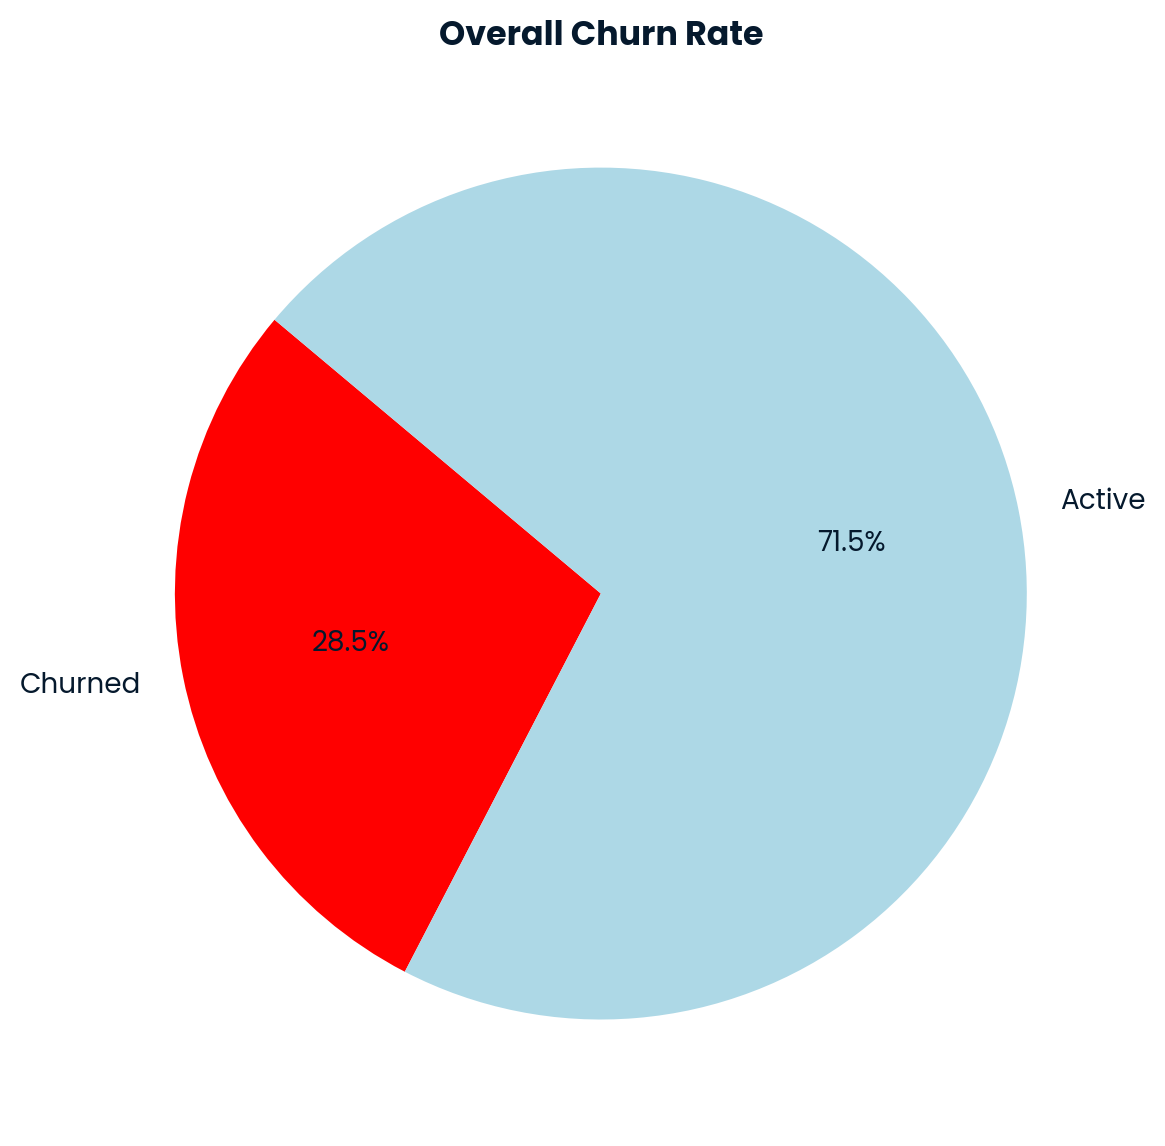

In [15]:
# overall churn distribution

overall_churn = final_df["churn_flag"].value_counts().sort_index(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(
    overall_churn.values,
    labels=["Churned", "Active"],
    colors=["red", "lightblue"],
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Overall Churn Rate", weight='bold')
plt.tight_layout()
plt.show()

## 4.2 Customer Profile & Activity

### 4.2.1 Number of Customers by Plan

**Observation:** The Basic plan has the largest customer base (118), followed by Free (105), Enterprise (92), and Pro (85), indicating a clear concentration in the lower tier plans.

**Insight:** Customer distribution skews toward entry level tiers, suggesting that either the value proposition of higher tier plans is not compelling enough or customers are price sensitive. This highlights an opportunity to reposition or repackage Pro and Enterprise to increase perceived value and drive upgrades.



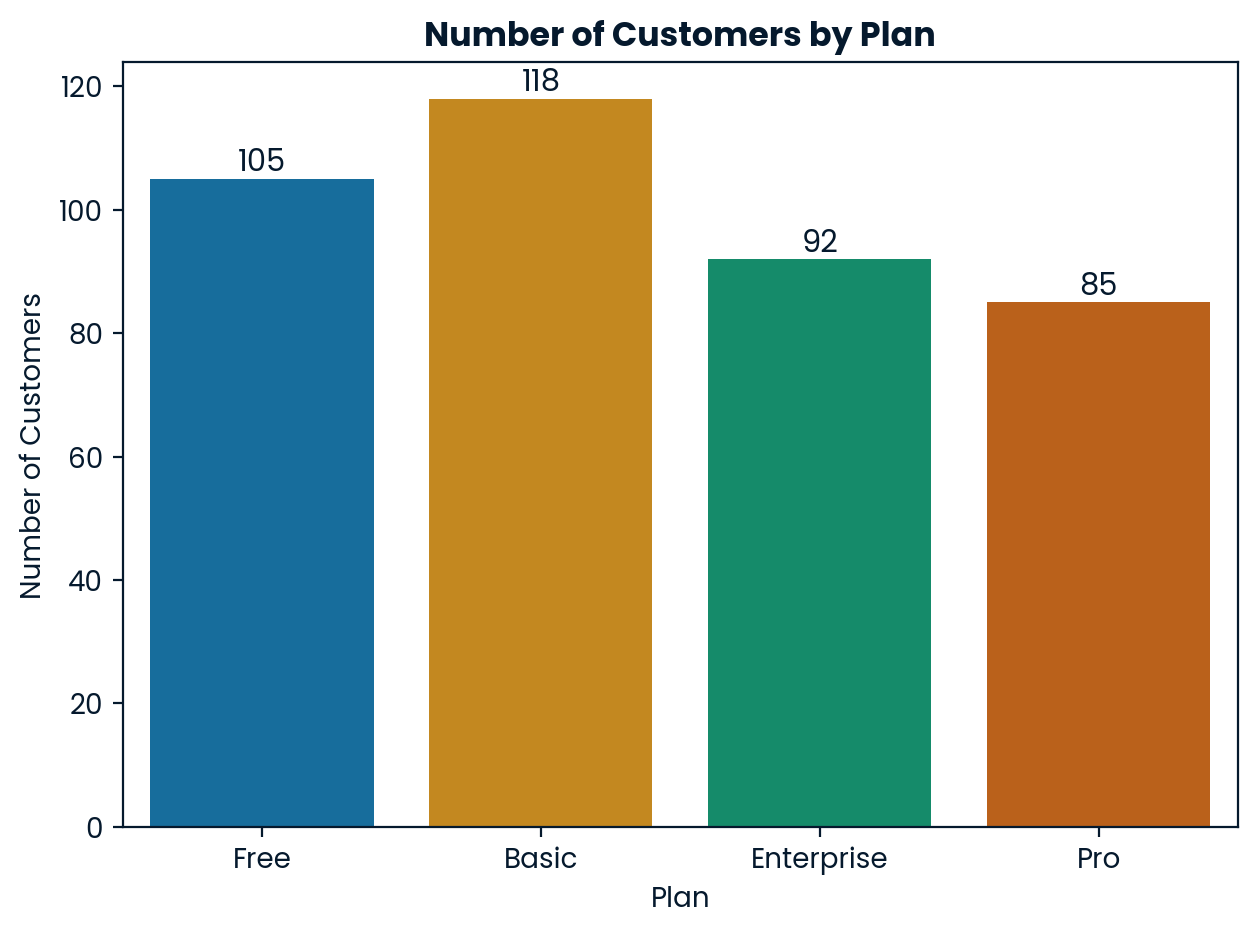

In [16]:
# number of customers by plan

plan_order = ["Free", "Basic", "Enterprise", "Pro"]
plan_counts = final_df["plan"].value_counts().reindex(plan_order)

cbf = sns.color_palette("colorblind")

ax = sns.barplot(x=plan_counts.index, y=plan_counts.values, palette=cbf)
plt.title("Number of Customers by Plan", weight='bold')
plt.xlabel("Plan")
plt.ylabel("Number of Customers")

for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()

### 4.2.2 Support Ticket Volume per User

**Observation:** Support demand is heavily concentrated among low ticket users: roughly 100 users submit only 1–2 tickets, and the number of users declines sharply as ticket volume increases, with fewer than 10 users generating 7–8 tickets.

**Insight:** A small segment of high ticket users is disproportionately driving support load, indicating potential friction points or unmet needs within this group. Targeted interventions such as proactive outreach, onboarding reinforcement, or workflow specific fixes could significantly reduce overall support volume and improve satisfaction.

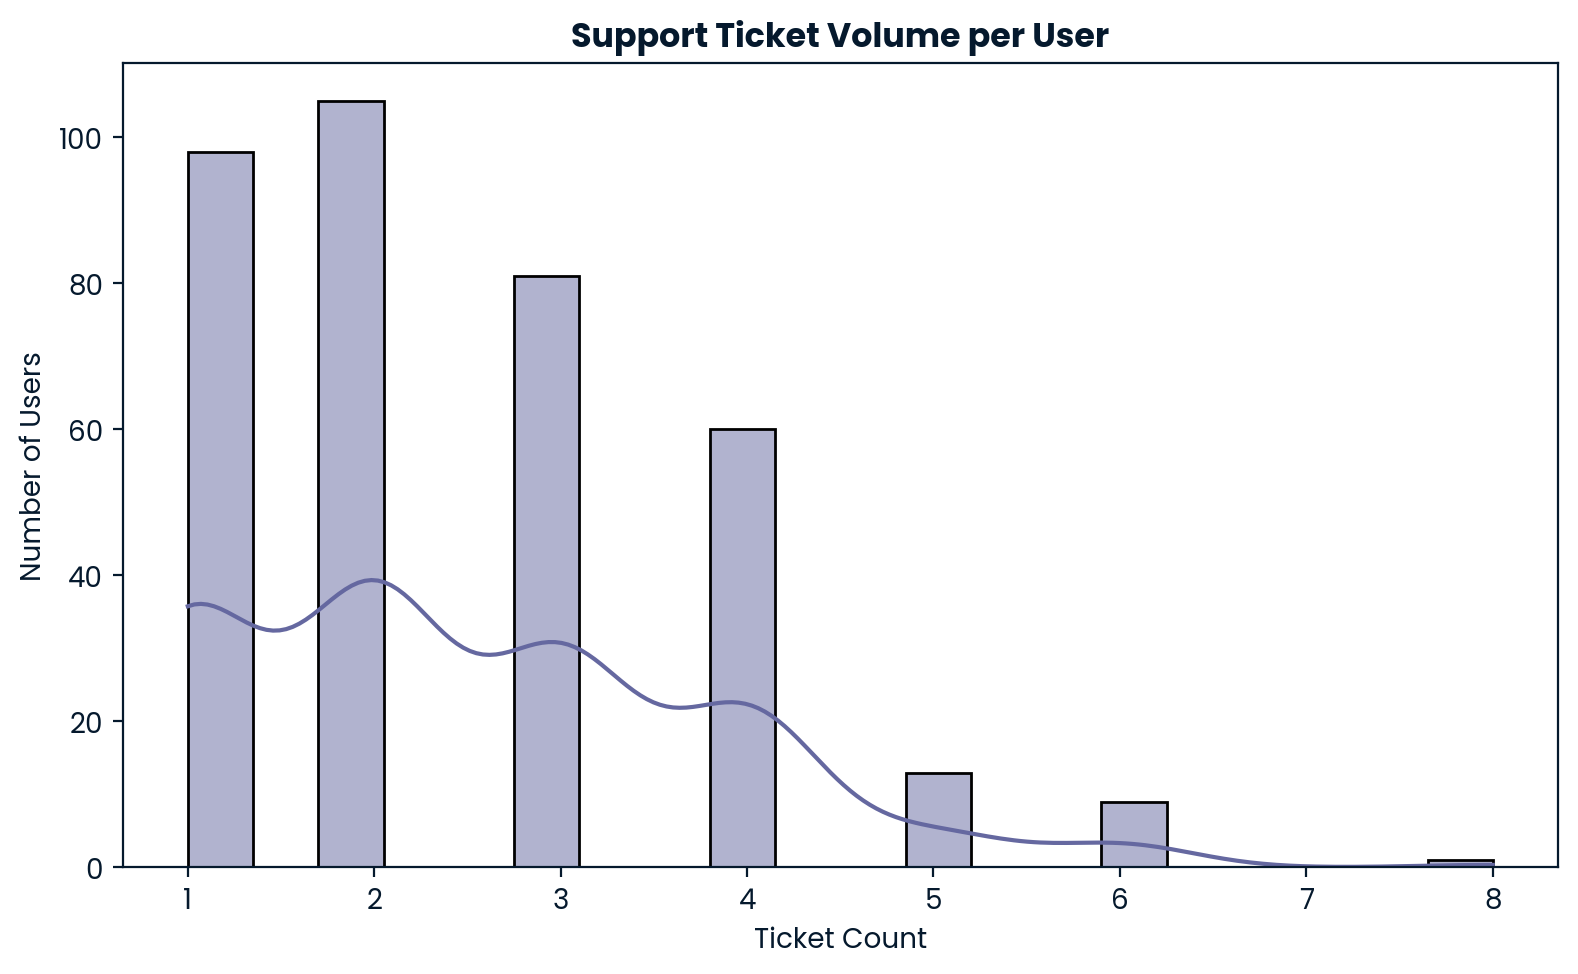

In [17]:
# support ticket volume per user

support_volume = customer_support.groupby('user_id').size().reset_index(name='ticket_count')

plt.figure(figsize=(8,5))
sns.histplot(support_volume['ticket_count'], bins=20, kde=True)
plt.title('Support Ticket Volume per User', weight='bold')
plt.xlabel('Ticket Count')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()

### 4.2.3 Support Ticket Volume by Topic

**Observation:** Support demand is evenly distributed across all four topics, with each category generating a similar number of tickets. Billing shows the highest volume, while technical is slightly lower, but no single topic dominates.

**Insight:** Because ticket volume is balanced across topics, support strain isn’t driven by one specific issue type. This suggests that systemic improvements such as clearer documentation, better onboarding, or more intuitive product flows may have broader impact than topic specific fixes. Billing’s slight lead indicates a secondary opportunity to streamline payment workflows or clarify policies.

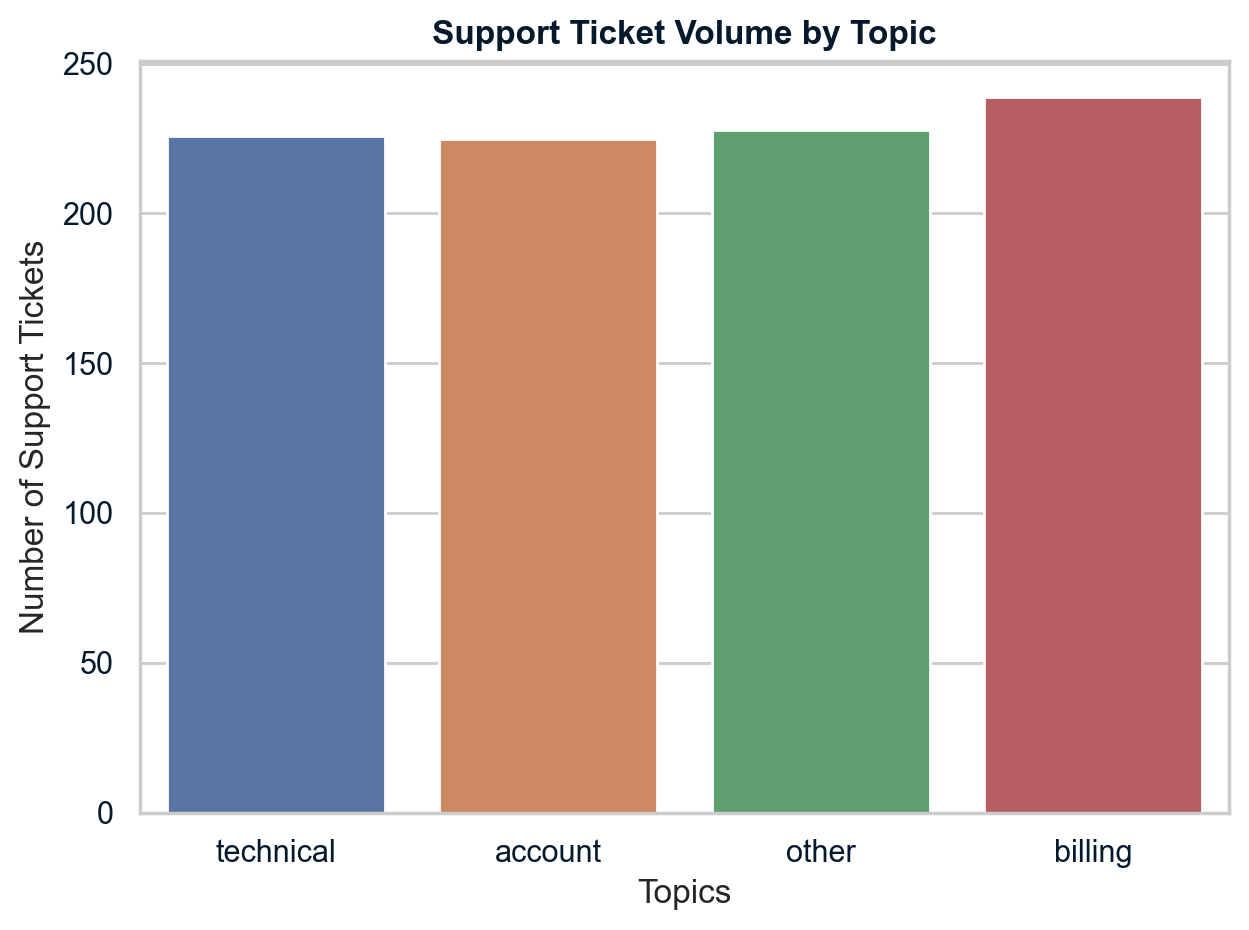

In [18]:
# churn vs support topic

# Set visual style
sns.set(style="whitegrid")

order = ['technical', 'account', 'other', 'billing']

ax=sns.countplot(data=customer_support, x='topic', hue='topic', order=order)
plt.title('Support Ticket Volume by Topic', weight='bold')
plt.xlabel('Topics')
plt.ylabel('Number of Support Tickets')
plt.tight_layout()
plt.show()

## 4.3 Churn by Customer Segments

### 4.3.1 Churn Rate by Plan Type

**Observation:** Among Free plan subscribers specifically, the churn rate reaches 41%, dramatically higher than all paid plans, which range between approximately 22% and 26%. The Pro plan has the lowest churn rate overall at 22.4%.

**Insight:** Churn is disproportionately concentrated among Free tier users, indicating that many never convert or fail to find early value. This highlights a strategic opportunity to strengthen activation, onboarding, and early engagement for Free users, while also refining upgrade pathways to reduce drop off before monetization.

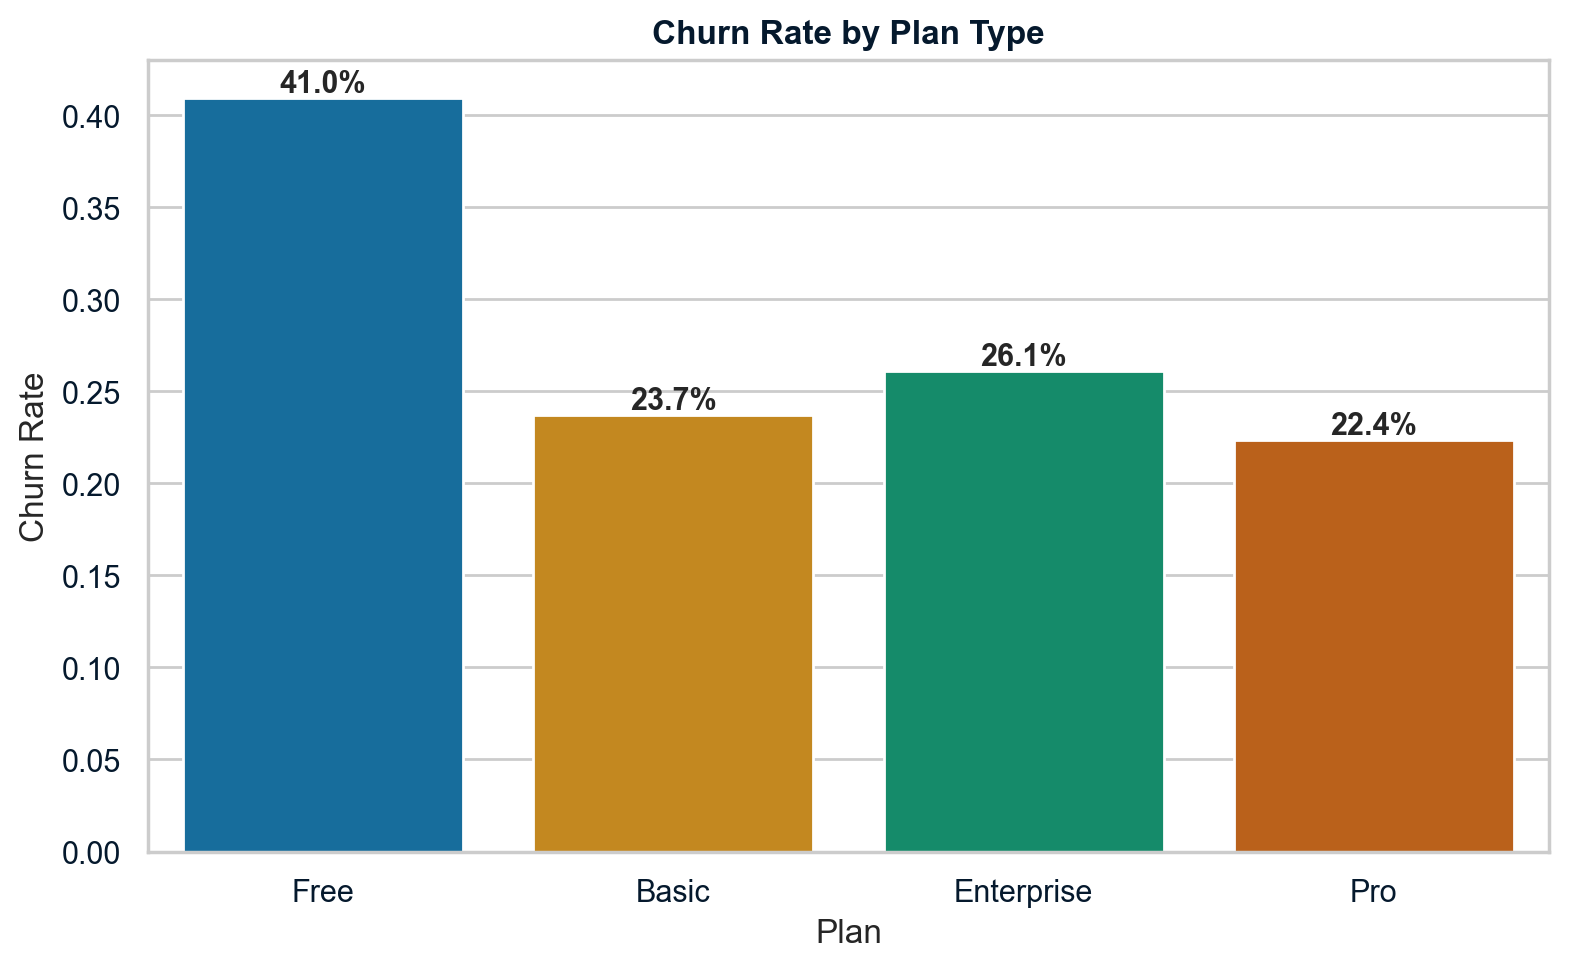

In [19]:
# churn rate by plan type

# Set visual style
sns.set(style="whitegrid")

order = ["Free", "Basic", "Enterprise", "Pro"]

plt.figure(figsize=(8,5))
ax = sns.barplot(
    data=account_info,
    x='plan',
    y='churn_flag',
    palette=cbf,
    ci=None,
    order=order
)

# Add % labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height*100:.1f}%",                     # format as percentage
        (p.get_x() + p.get_width() / 2, height),  # position at top center
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.title('Churn Rate by Plan Type', weight='bold')
plt.ylabel('Churn Rate')
plt.xlabel('Plan')
plt.tight_layout()
plt.show()

### 4.3.2 Churn Rate by State: Highest and Lowest Performers

**Observation:** Geographic churn varies dramatically across states, with the highest-churn state (New Jersey) exceeding 60% and the lowest (Arizona) falling near 10%, a six-fold spread.

**Insight:** The large spread in churn rates suggests that geographic factors such as market maturity, competition, or regional product fit differences may be influencing customer behavior. High churn states represent priority targets for localized retention strategies, while low churn states may offer patterns worth replicating elsewhere.

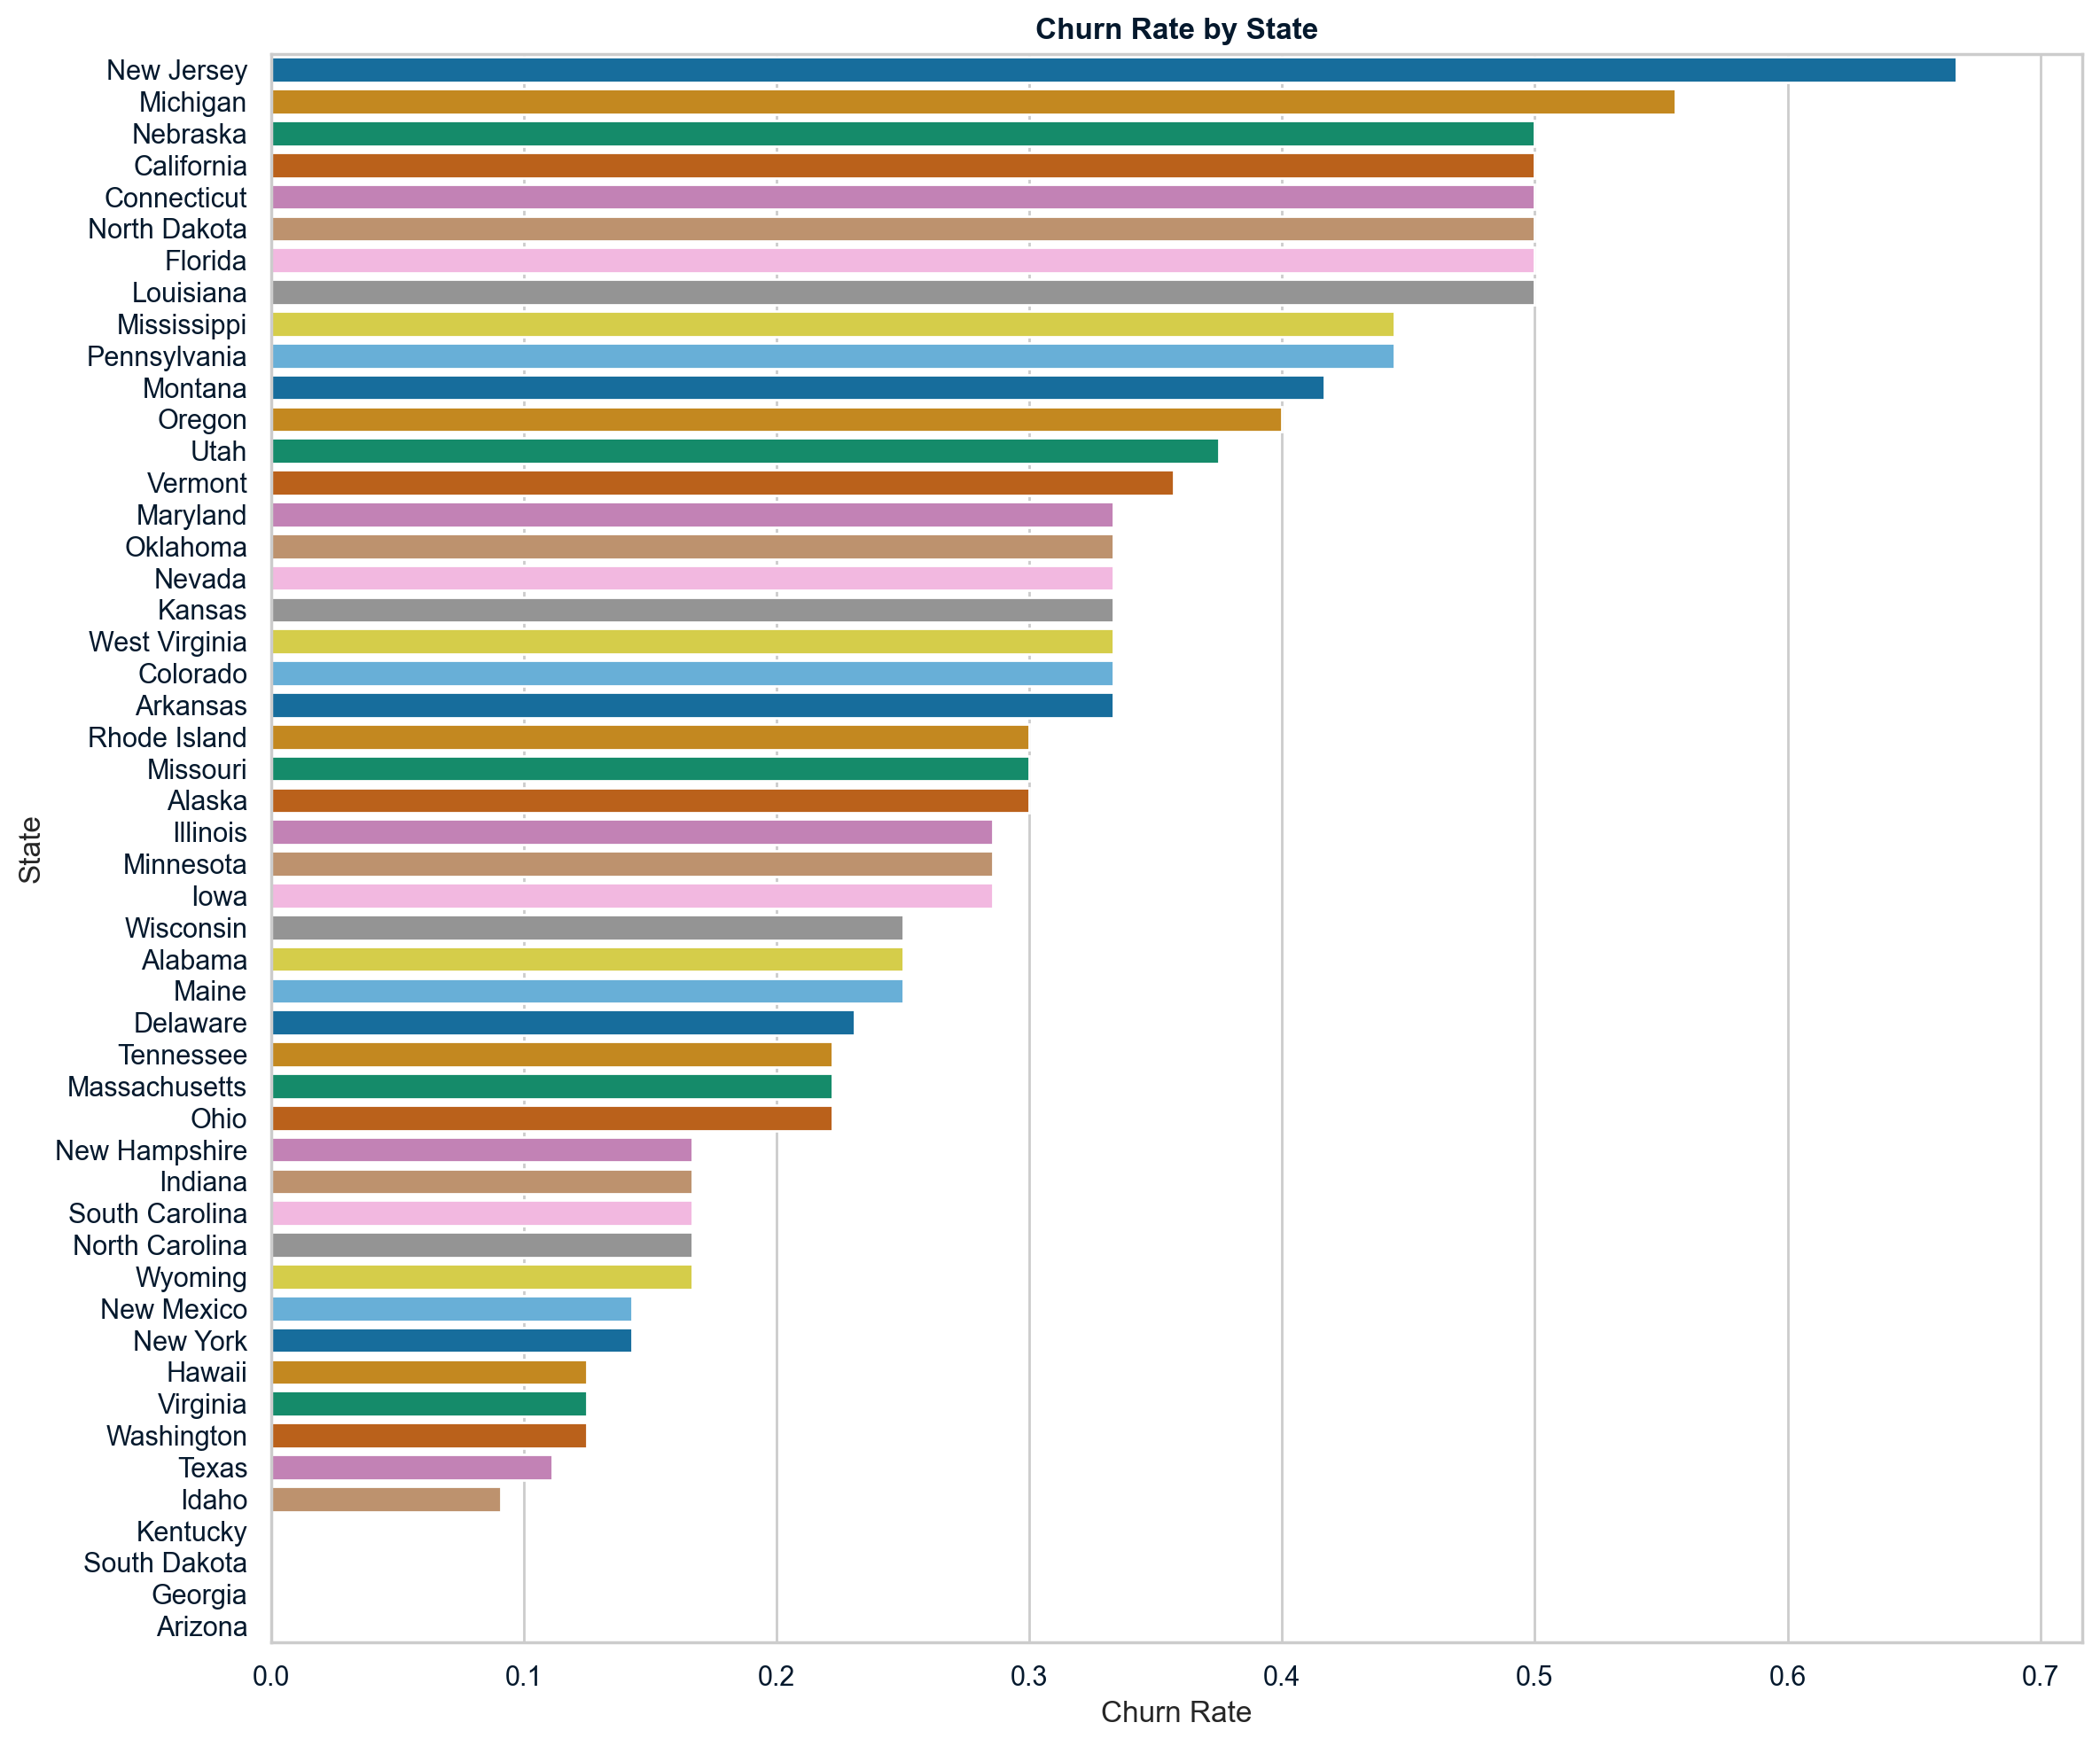

In [20]:
# churn rate by state - made horizontal for better readability

state_churn = (
    final_df.groupby("state")["churn_flag"]
    .mean()
    .sort_values(ascending=False)
    .head(50)
    .reset_index()
)

plt.figure(figsize=(12,10))
sns.barplot(
    data=state_churn,
    x="churn_flag",
    y="state",
    palette=cbf
)

plt.title("Churn Rate by State", weight='bold')
plt.xlabel("Churn Rate")
plt.ylabel("State")
plt.xlim(0, state_churn["churn_flag"].max() + 0.05)
plt.tight_layout()
plt.show()

## 4.4 Support‑Related Churn Drivers

### 4.4.1 Churn Rate by Support Ticket Count

**Observation:** Churn rates remain relatively stable (around 27–33%) for users with 1–6 support tickets, but spike dramatically to 100% for users with 8 tickets, indicating a sharp churn escalation among the highest‑ticket users.

**Insight:** High ticket users appear to hit a breaking point where repeated support interactions correlate with near certain churn. This suggests that unresolved or recurring issues are compounding. Prioritizing rapid escalation paths, root cause fixes, and proactive intervention for users crossing the 4–5 ticket threshold could meaningfully reduce churn among this at risk segment.

**Note:** The 100% churn rate at 8 tickets is based on a small number of users and should be interpreted with caution. The trend is nonetheless meaningful. Churn escalates consistently as ticket count rises, and the pattern across the broader 1–6 ticket range (27–33%) is based on sufficient sample sizes to be reliable.

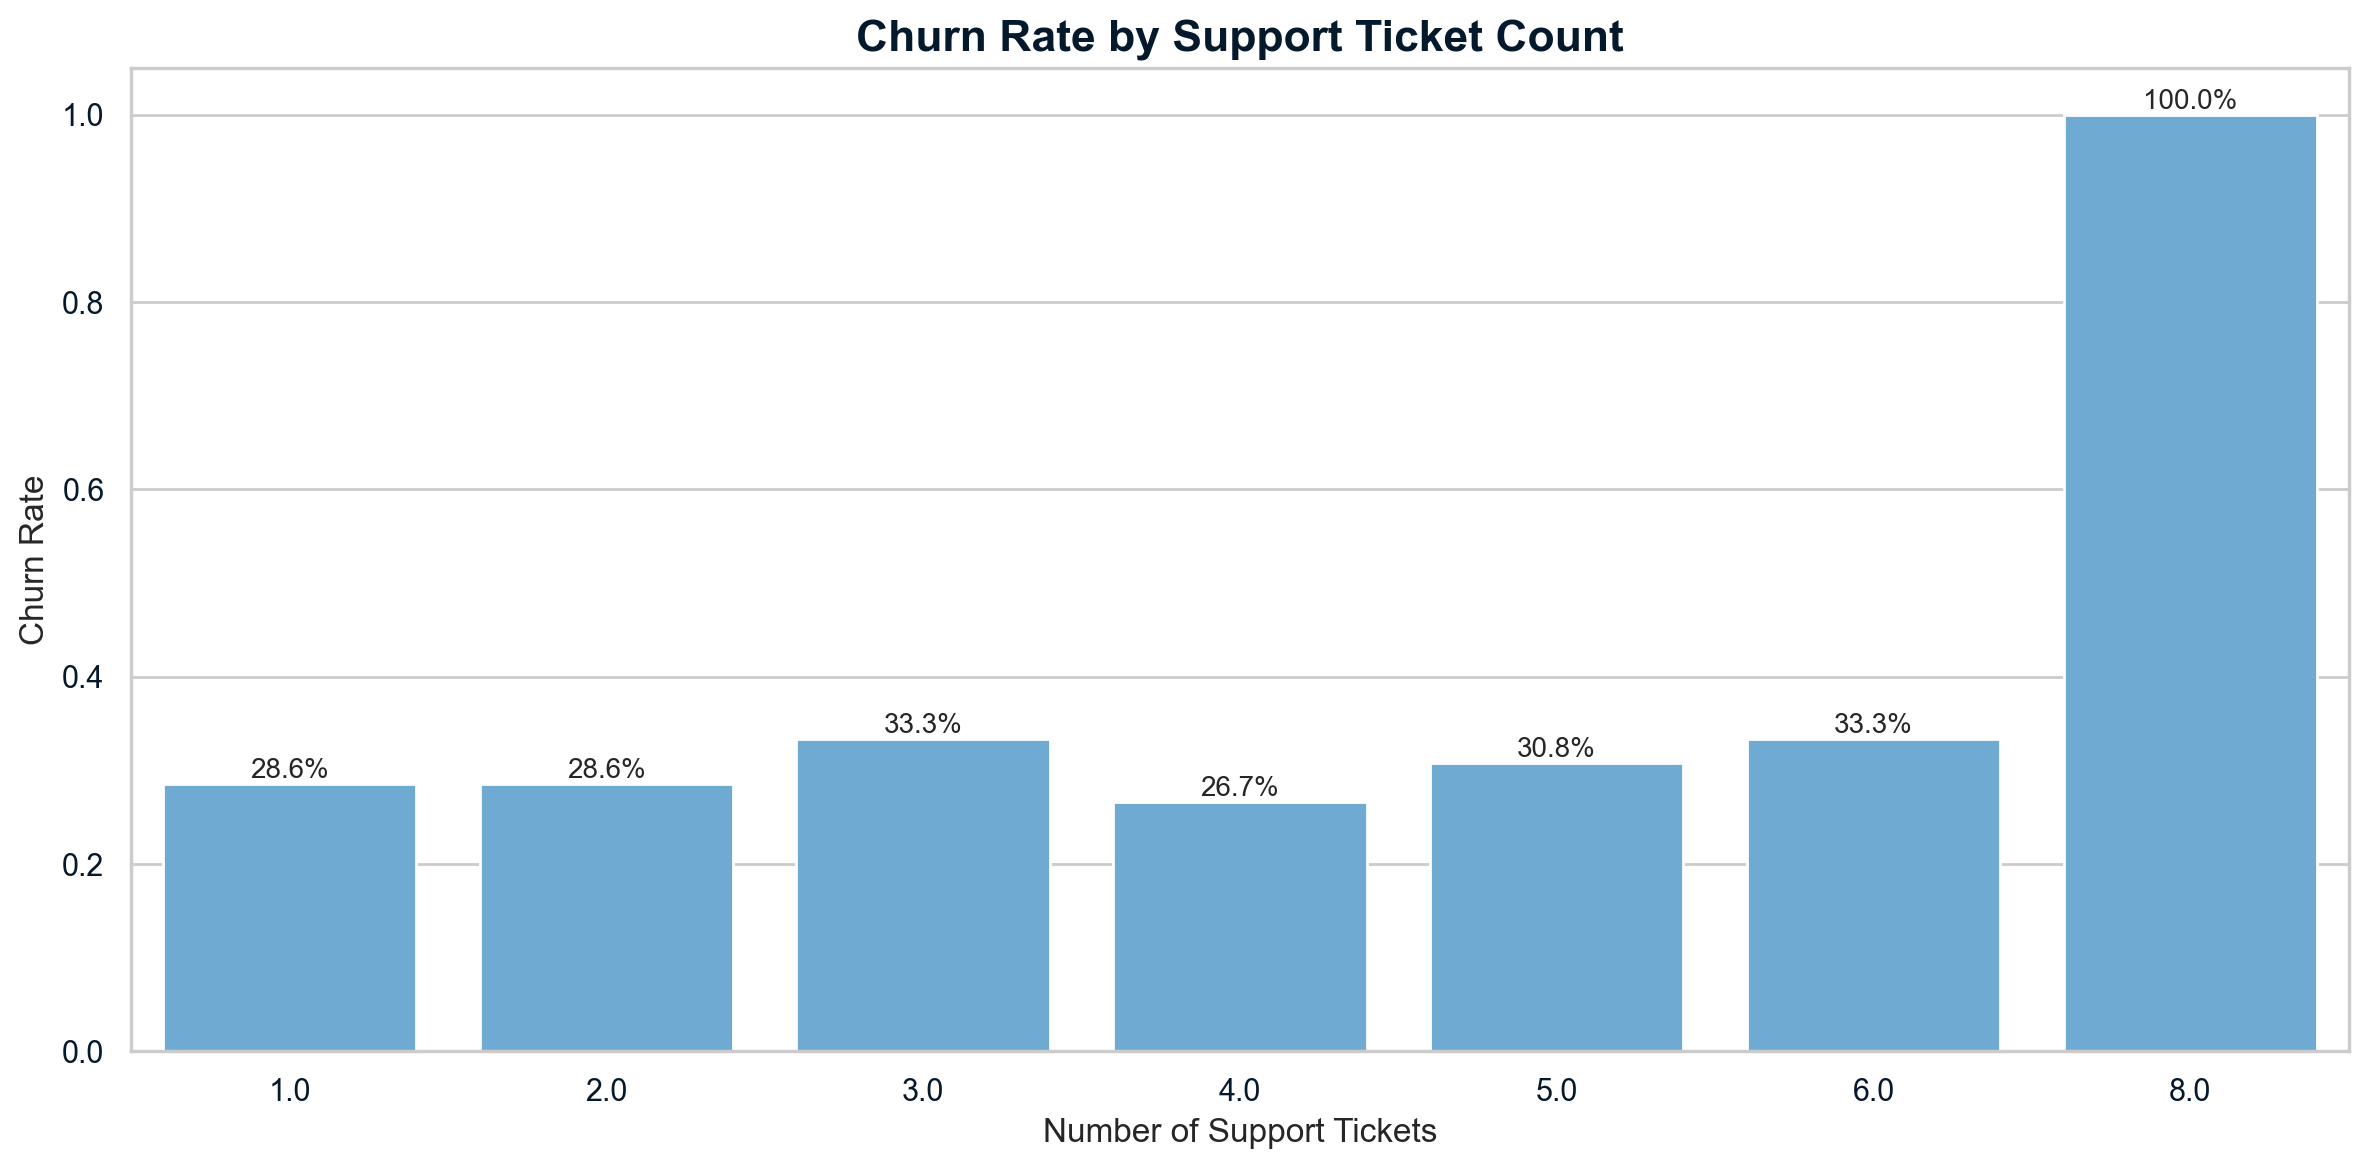

In [21]:
# support ticket count vs churn

# Compute churn rate by exact ticket count

ticket_churn = (
    final_df.groupby('total_tickets')['churn_flag']
      .mean()
      .reset_index()
)

# Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=ticket_churn,
    x='total_tickets',
    y='churn_flag',
    color='#5DADE2'
)

plt.title("Churn Rate by Support Ticket Count", fontsize=16, weight='bold')
plt.xlabel("Number of Support Tickets", fontsize=12)
plt.ylabel("Churn Rate", fontsize=12)

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1%}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


### 4.4.2 Churn Rate by Support Topic

**Observation:** Churn rates are relatively similar across support topics, ranging from 24.7% to 32.2%. Billing issues show the highest churn (32.2%), while account related issues show the lowest (24.7%). Technical and “other” topics sit at roughly the same level (31%).

**Insight:** Because churn is elevated across most support topics (especially billing and technical), customers who contact support for these issues may be experiencing friction that directly impacts retention. Strengthening billing clarity, technical reliability, and self service pathways could reduce churn across multiple segments rather than solving for a single isolated issue.

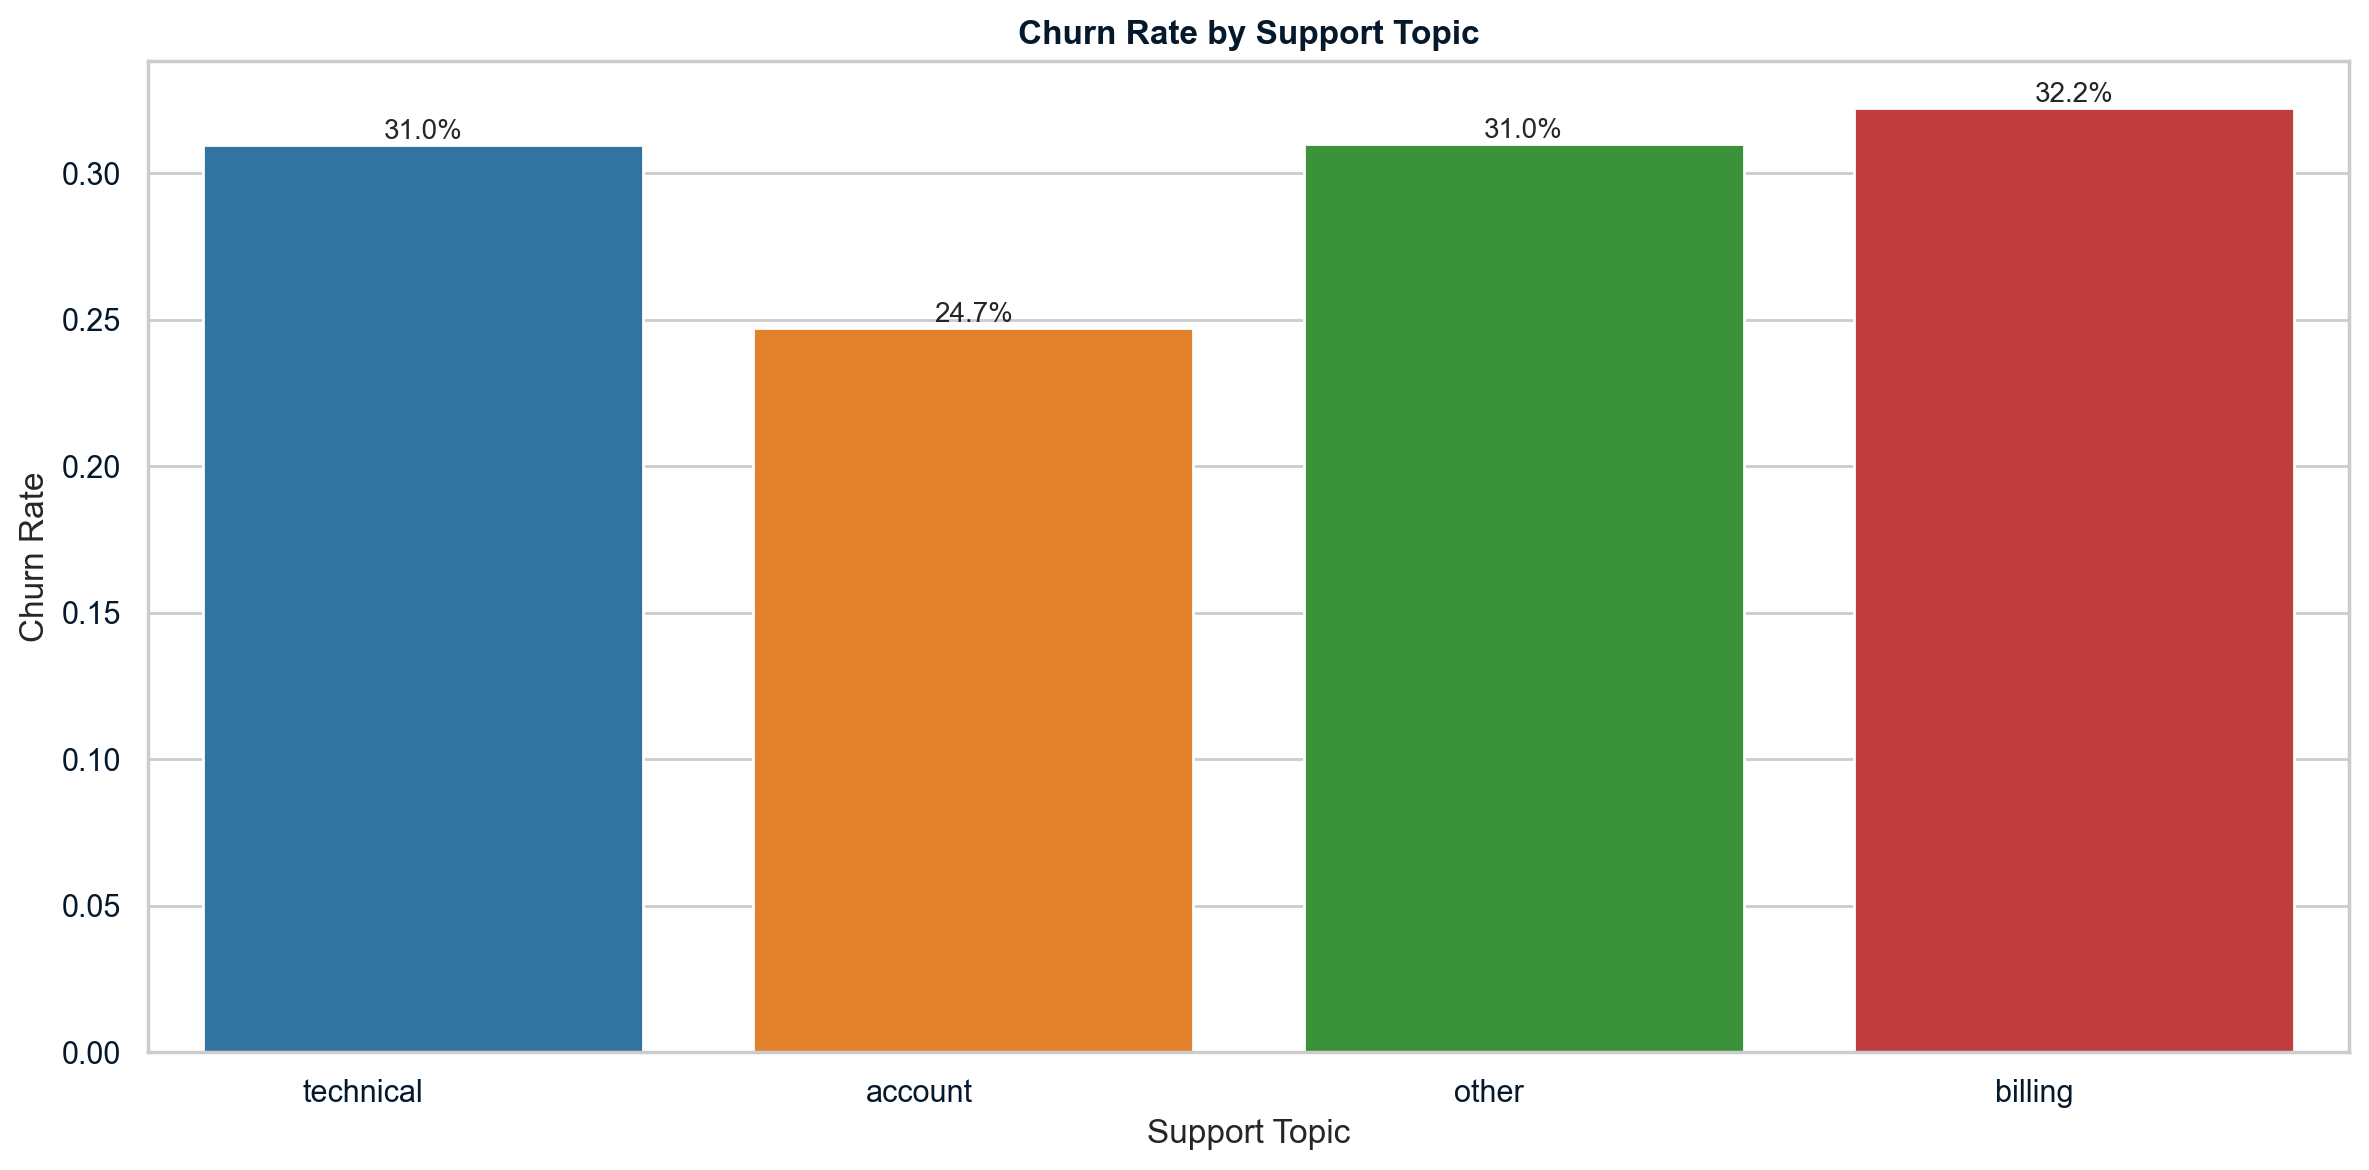

In [22]:
# churn rate by support topic

# Set visual style
sns.set(style="whitegrid")

# Calculate churn rate per support topic
topic_churn = (
    final_df.groupby('topic')['churn_flag']
      .mean()
      .reset_index()
      .rename(columns={'churn_flag': 'churn_rate'})
)

order = ['technical', 'account', 'other', 'billing']

# Sort topics by churn rate (optional but improves readability)
topic_churn = topic_churn.sort_values('churn_rate', ascending=False)

custom_palette = {
    'technical': '#1f77b4',  # blue
    'account':   '#ff7f0e',  # orange
    'other':     '#2ca02c',  # green
    'billing':   '#d62728'   # red
}

# --- 2. Plot ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=topic_churn,
    x='topic',
    y='churn_rate',
    palette=custom_palette,
    order=order
)

# --- 3. Formatting ---
plt.title("Churn Rate by Support Topic", weight='bold')
plt.xlabel("Support Topic")
plt.ylabel("Churn Rate")
plt.xticks(ha='right')

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.1%}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 4.4.3 Average Resolution Time by Churn Status

**Observation:** Churned customers experience significantly longer resolution times. The median average resolution time across churned users is approximately 18–20 hours, with a wide spread in variability. Active customers show a median average of approximately 6–7 hours and a much tighter, more consistent distribution.

**Insight:** Longer and more inconsistent resolution times are strongly associated with churn, suggesting that delays in resolving issues impact customer retention. Improving support responsiveness, case routing, and first contact resolution could meaningfully reduce churn by ensuring customers receive timely, predictable help.

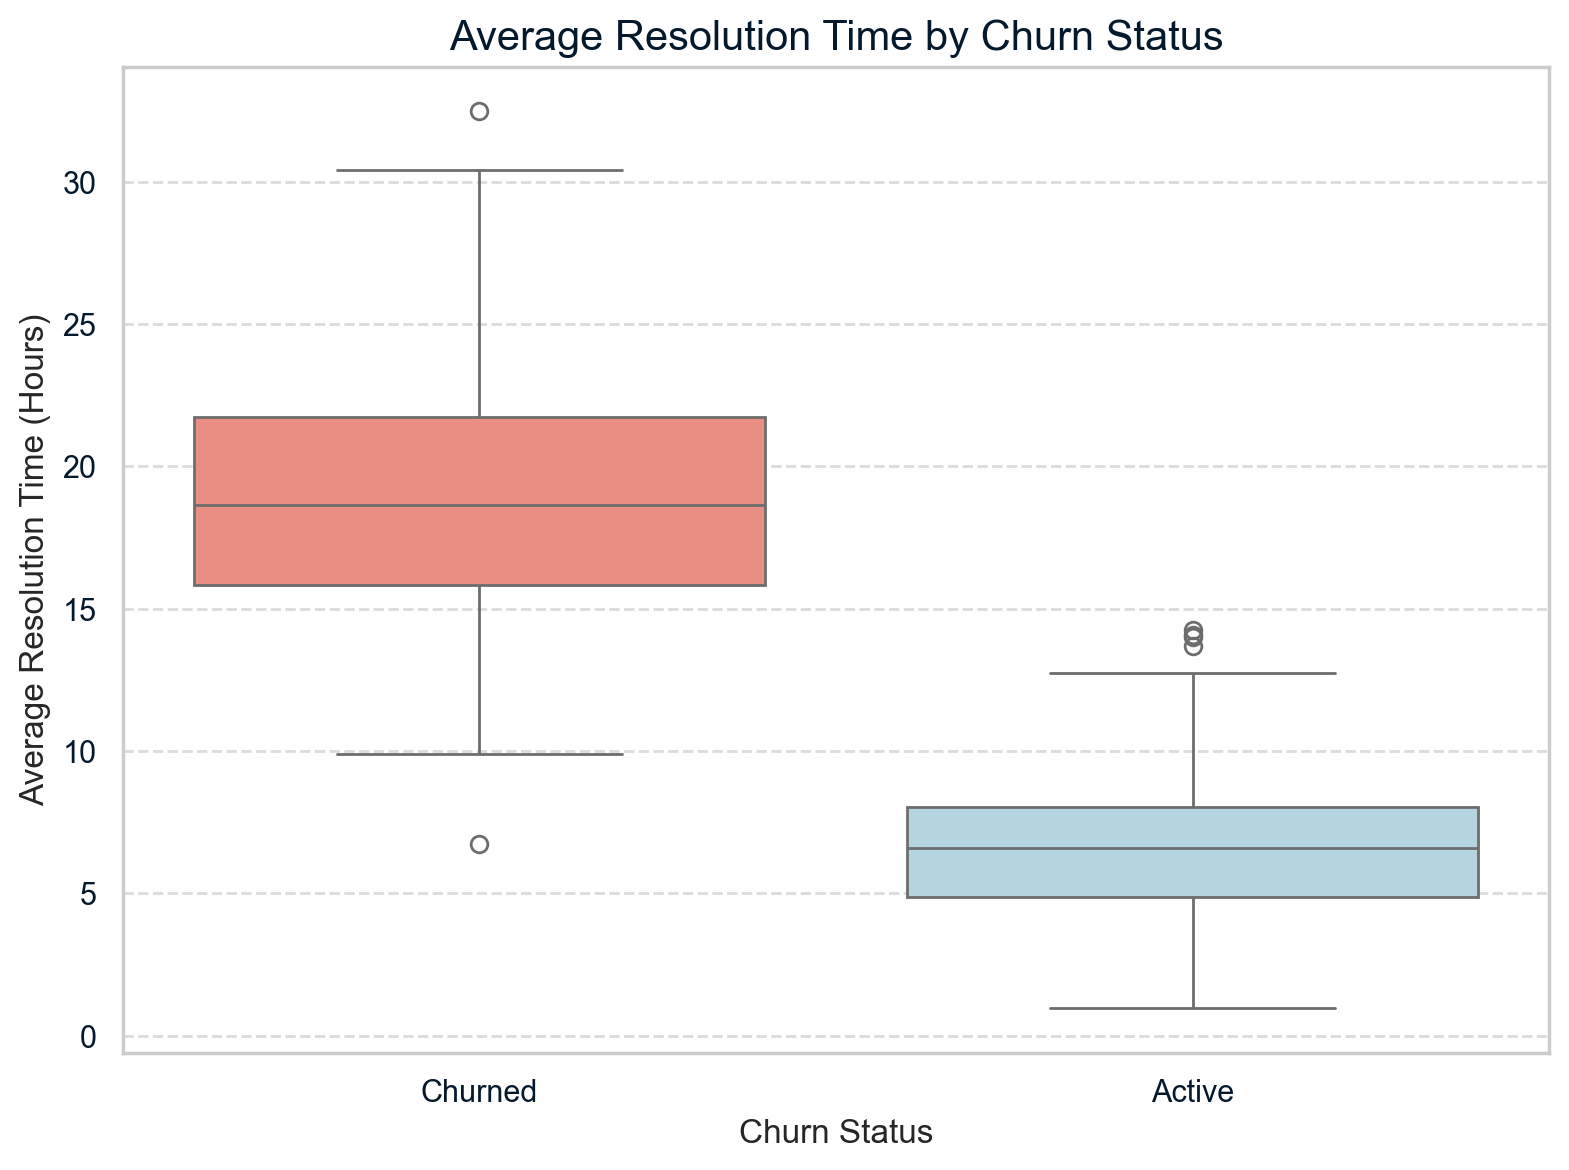

In [23]:
# resolution time vs churn

plt.figure(figsize=(8,6))

sns.boxplot(
    data=final_df,
    x='churn_status',
    y='avg_resolution_time',
    palette={'Churned': 'salmon', 'Active': 'lightblue'}
)

plt.title('Average Resolution Time by Churn Status', fontsize=15)
plt.xlabel('Churn Status', fontsize=12)
plt.ylabel('Average Resolution Time (Hours)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 4.5 Engagement‑Related Churn Drivers

### 4.5.1 Engagement Distribution by Churn Status

**Observation:** Churned customers show a sharp engagement drop off, with most clustering around one total event, while active customers display a broader, higher engagement distribution with peaks around 2–4 events.

**Insight:** Low engagement is a strong behavioral signal for churn. Customers who interact only once are far more likely to leave, while sustained activity correlates with retention. This highlights the value of early stage engagement nudges, such as guided onboarding, activation emails, or in product prompts, to move users beyond the “one event” risk zone.

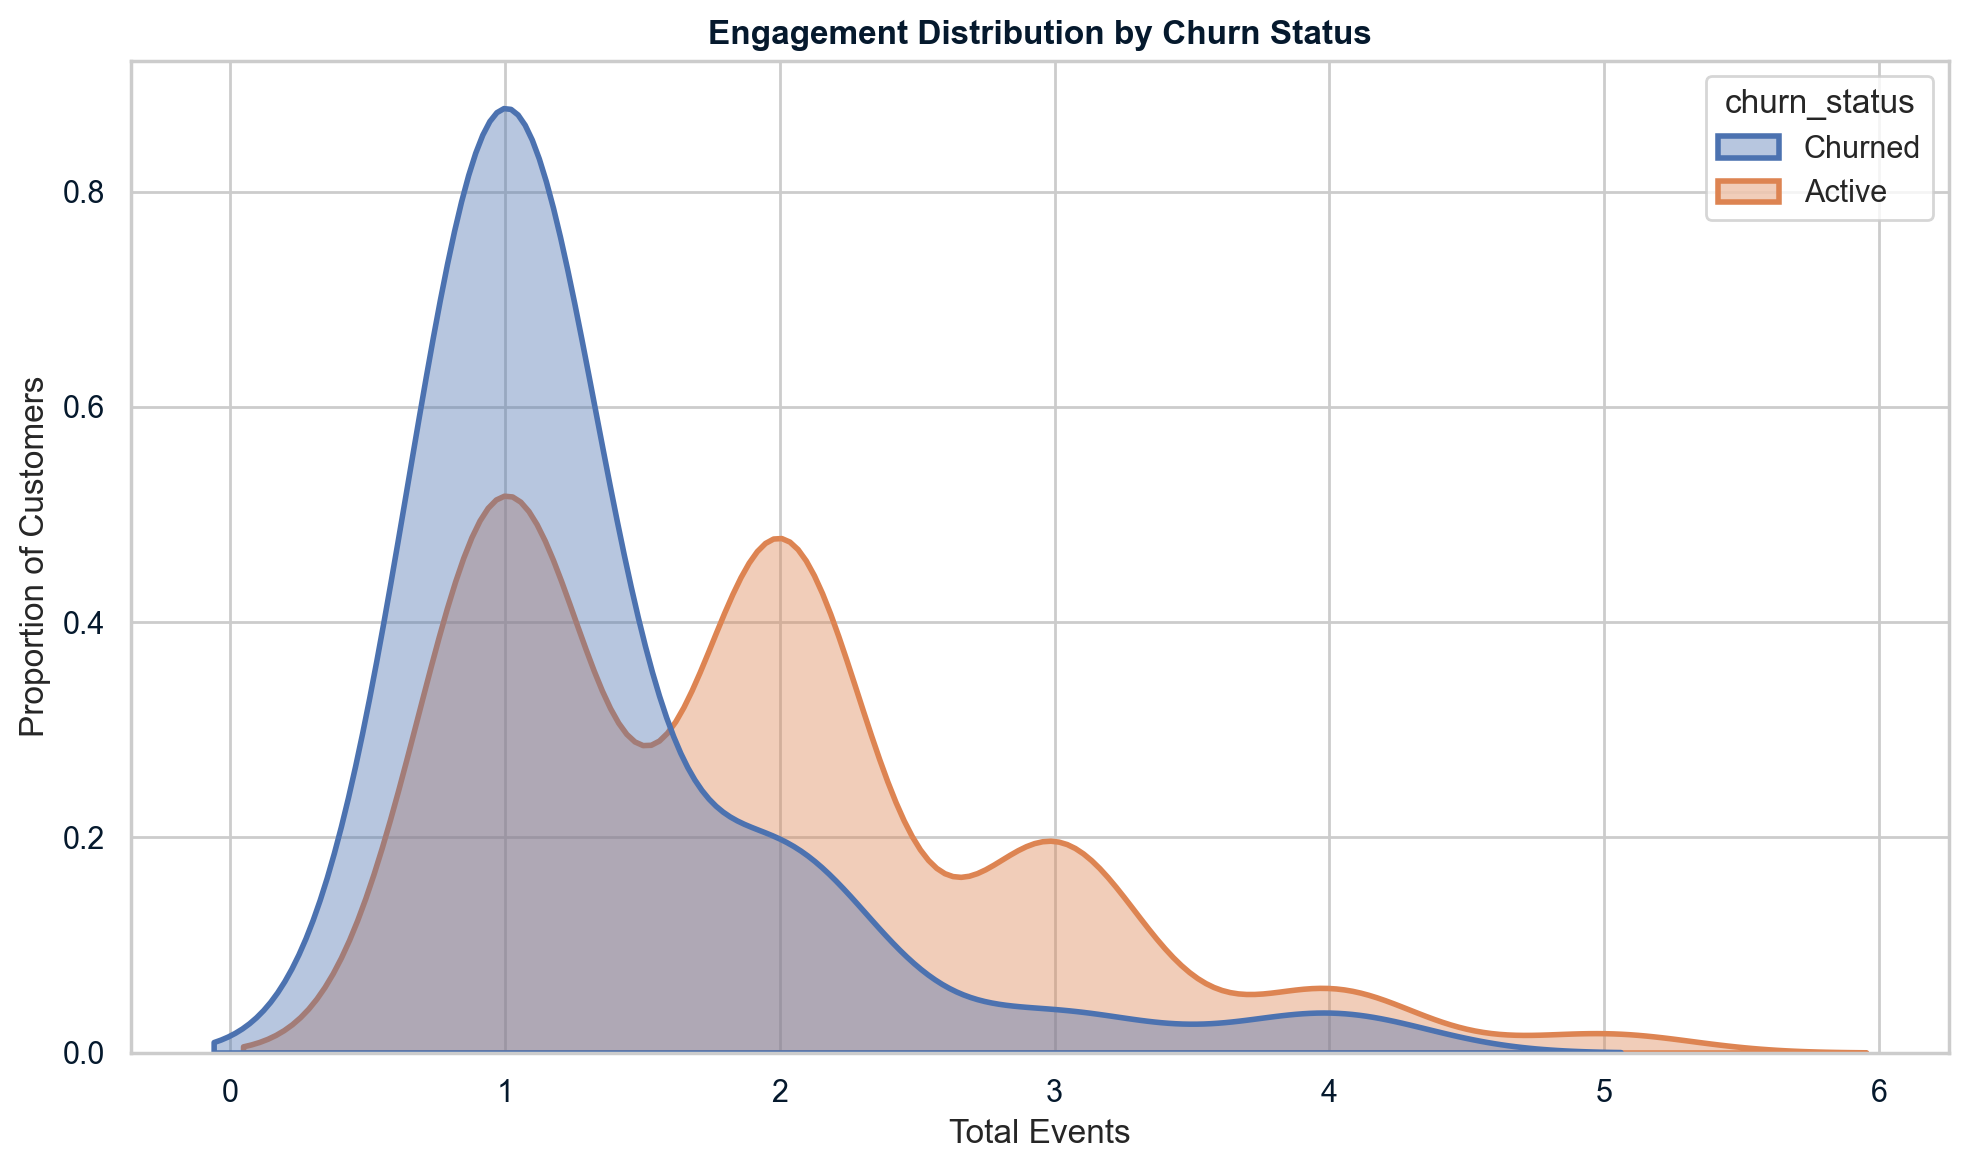

In [24]:
# engagement distribution by churn status

plt.figure(figsize=(10,6))

sns.kdeplot(
    data=final_df,
    x="total_events",
    hue="churn_status",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2
)

plt.title("Engagement Distribution by Churn Status", weight='bold')
plt.xlabel("Total Events")
plt.ylabel("Proportion of Customers")
plt.tight_layout()
plt.show()

### 4.5.2 Support Load by Engagement and Churn Status

**Observation:** Customers with only 1–2 engagements generate the majority of support tickets. Among active users, those with 1 engagement generated 172 tickets and those with 2 engagements generated 185, together accounting for the large majority of total support volume.

**Insight:** Low engagement is strongly associated with higher support demand. Users who haven’t meaningfully interacted with the product require more help and are more likely to churn. This suggests that improving early stage onboarding, guided activation, and self service resources could simultaneously reduce support volume and strengthen retention by moving customers into higher engagement behaviors.

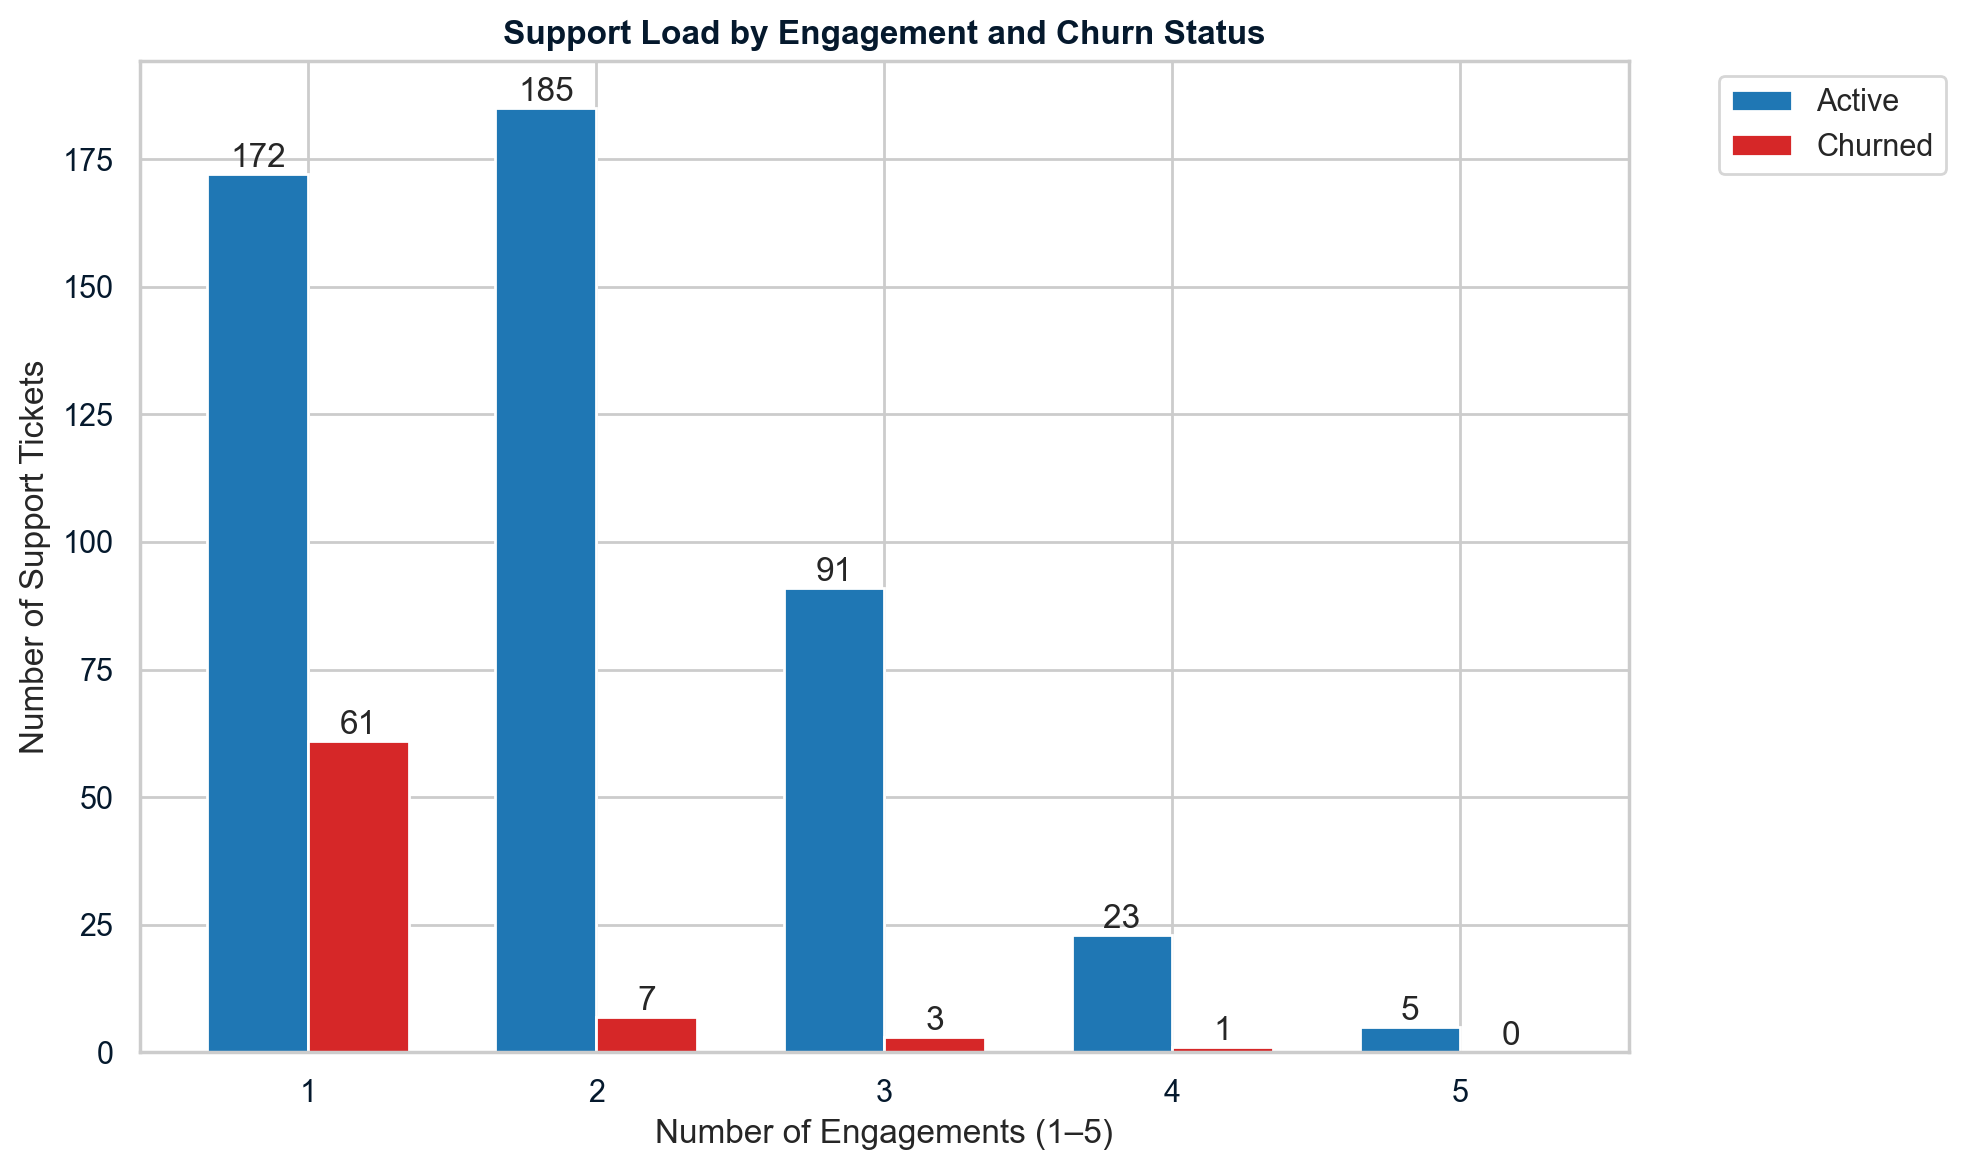

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# --- Define the engagement levels you expect ---
events = [1, 2, 3, 4, 5]

# --- Aggregate ticket counts ---
agg = (
    final_df
    .groupby(['total_events', 'churn_flag'])['total_tickets']
    .sum()
    .unstack(fill_value=0)
)

# Ensure all engagement levels 1–5 exist
agg = agg.reindex(events, fill_value=0)

# Ensure churn_flag columns exist (0 = active, 1 = churned)
agg = agg.reindex(columns=[0, 1], fill_value=0)

not_churned = agg[0].values   # Active customers
churned = agg[1].values       # Churned customers

# --- Plot setup ---
x = np.arange(len(events))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width/2, not_churned, width, label='Active', color='#1f77b4')
bars2 = plt.bar(x + width/2, churned, width, label='Churned', color='#d62728')

plt.xticks(x, events)
plt.xlabel('Number of Engagements (1–5)')
plt.ylabel('Number of Support Tickets')
plt.title('Support Load by Engagement and Churn Status', weight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- Add value labels ---
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha='center',
        va='bottom'
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.0f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 5. Business Metrics

### Primary KPI: Monthly Subscriber Churn Rate

Measures the percentage of subscribers who cancel their subscription in a given month. This is the headline metric of the analysis and the clearest measure of whether retention strategies are working.

`Current Baseline:` 28.5% of the 400-subscriber base has churned, with significant variation by plan tier: Free (41%), Enterprise (26.1%), Basic (23.7%), and Pro (22.4%). These figures establish the starting point against which all future retention efforts should be measured.

`Target Performance:` Reduce overall monthly churn rate to below 20% within two quarters by implementing the interventions outlined in Section 6.

### Secondary KPI: Average Support Ticket Resolution Time.

Measures the average number of hours taken to resolve a support ticket per subscriber. The median of these per-user averages is used as the central benchmark, as it is robust to the outliers visible in the churned group.

`Current Baseline:` Active subscribers have a median average resolution time of approximately 6–7 hours. Churned subscribers experienced a median average of approximately 18–20 hours, nearly three times longer. This indicates that slow or inconsistent support handling is a material contributor to cancellation decisions.

`Target Performance:` Reduce median average resolution time to ≤ 8 hours across all subscribers, bringing at-risk customers in line with the performance level currently experienced by active subscribers.

### Operational Implementation

**Formalize an 8-Hour SLA:** Implement a company-wide Service Level Agreement requiring all support tickets to be resolved within 8 hours. Communicate this expectation across Support, Product, and Customer Success teams.

**High-Risk Ticket Flagging:** Automatically flag any ticket exceeding 12 hours as a high churn-risk case, triggering priority handling and escalation to a senior agent.

**Billing Ticket Prioritization:** Billing-related tickets approaching the SLA threshold should be routed to specialist agents or fast-track queues, given that billing issues carry the highest churn rate at 32.2%.

**Automated Retention Interventions:** For tickets trending toward a delayed resolution, activate retention workflows such as proactive check-ins, goodwill credits, or expedited follow-ups to address dissatisfaction before a cancellation decision is made.

**Performance-Based Recognition:** Track resolution times at the agent level and recognise those who consistently meet or exceed the 8-hour benchmark, reinforcing the behaviours most directly associated with subscriber retention.

## 6. Key Findings and Recommendations

**Key Finding 1:** Overall churn stands at 28.5%, affecting more than 1 in 4 subscribers.

`Recommendation:` Build a risk scoring alert that flags users showing multiple churn signals simultaneously such as low engagement, rising ticket counts, or billing issues that trigger a retention outreach sequence before they reach a cancellation decision.

**Key Finding 2:** Free plan subscribers churn at a rate of 41%, the highest churn rate of any plan tier. 

`Recommendation:` Redesign Free plan onboarding into a structured 14-day activation sequence targeting at least 3 engagement events. Any Free user completing 3 or more events within 14 days should automatically receive a time-limited upgrade offer, targeting the moment of highest perceived value.

**Key Finding 3:** Geographic churn varies dramatically, with the highest-churn state (New Jersey) exceeding 60% and the lowest (Arizona) falling near 10%.

`Recommendation:` Deploy geo targeted retention campaigns in the highest-churn states, while investigating the conditions driving low churn in states like Arizona and Georgia to replicate those patterns in high-risk markets.

**Key Finding 4:** Churned customers experienced support resolution times nearly 3× longer than active customers (median 18–20 hours vs. 6–7 hours).

`Recommendation:` Enforce the 8 hour resolution SLA defined in Section 5, with automatic escalation at 6 hours. Improve first assignment routing to reduce handoffs, and build a self service knowledge base to deflect common tickets before they enter the queue.

**Key Finding 5:** Billing support topics carry the highest churn rate of any topic at 32.2%.

`Recommendation:` Audit the billing flow to identify friction points, prioritise billing tickets with specialist agents, and introduce proactive charge notifications and clearer pricing communications to reduce billing contacts before they occur.

**Key Finding 6:** Low engagement is the strongest behavioral predictor of churn, with churned customers clustering sharply around just 1 total engagement event.

`Recommendation:` Target users at the 1 event threshold with personalised prompts recommending a specific next action. Track the percentage of new users reaching 3 or more events within 30 days as a leading retention indicator. This metric should move in parallel with the primary churn rate KPI.

**Key Finding 7:** Users with 4 or more support tickets represent a critical at-risk segment, with all 8-ticket users churning.

`Recommendation:` At the 4th support ticket, trigger a personal outreach from a customer success representative to diagnose the recurring issue, offer a service credit to signal goodwill, and feed repeated issue patterns back into product and documentation improvements.

## 7. Final Summary 

This analysis examined subscriber churn at Fit.ly Tech using three integrated datasets covering account information, customer support interactions, and user engagement activity across 400 subscribers. The goal was to identify the primary drivers of the observed increase in churn and provide actionable, data-driven recommendations for leadership to implement in the upcoming quarter.

The analysis confirms that churn is being driven by a convergence of factors across plan type, geographic location, support experience, and engagement behaviour, rather than any single isolated cause. Free plan subscribers represent the highest churn segment with a 41% churn rate, pointing to an activation gap where users disengage before experiencing core product value. Geographic churn varies by as much as six-fold between states, suggesting that market specific factors warrant localised retention strategies. Support data reveals that churned customers waited nearly three times longer for ticket resolution than active customers, and that billing related issues carry the highest churn rate at 32.2%. Engagement data confirms that customers who record only a single interaction event are the most at risk of leaving.

Taken together, these findings indicate that churn at Fit.ly is largely preventable. The highest impact interventions are improving early stage onboarding for Free plan users, enforcing the 8-hour support resolution SLA defined in Section 5, and implementing proactive outreach for users showing low engagement or rising ticket counts. Progress against all three interventions should be measured primarily through the monthly subscriber churn rate, with the target of reducing the current 28.5% baseline to below 20% within two quarters. The secondary resolution time KPI will serve as an early signal of whether support improvements are taking hold ahead of churn rate movements.

GDPR Compliance Note: 46 data-erasure requests were identified in the customer support comments field. Legal and engineering teams should verify the fulfilment of all outstanding requests and implement a compliant, documented process for handling GDPR erasure requests going forward.